In [1]:

# ============================================================
# PROJECT: ML Problem Framing & Responsible Data Card
# TASK: Customer Churn Prediction
# NOTEBOOK: baseline_customer_churn.ipynb
# ============================================================


# CELL 1: IMPORT LIBRARIES

import pandas as pd
import numpy as np

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Libraries imported successfully!")


# CELL 2: CREATE DATASET

data = {
    "customer_id": [
        "C001", "C002", "C003", "C004",
        "C005", "C006", "C007", "C008",
        "C009", "C010", "C011", "C012"
    ],

    "tenure_months": [
        2, 18, 6, 30, 11, 1, 24, 8, 15, 4, 20, 7
    ],

    "support_tickets": [
        4, 1, 3, 0, 2, 5, 1, 4, 2, 3, 0, 2
    ],

    "monthly_spend_inr": [
        499, 1299, 799, 1499, 999, 499,
        999, 799, 1299, 499, 999, 799
    ],

    "last_login_days": [
        21, 2, 14, 1, 5, 30, 3, 17, 4, 12, 2, 9
    ],

    "plan_type": [
        "Basic", "Pro", "Basic", "Pro",
        "Standard", "Basic", "Standard", "Basic",
        "Pro", "Basic", "Standard", "Standard"
    ],

    "churned": [
        1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0
    ]
}

df = pd.DataFrame(data)

print("\nDATASET CREATED SUCCESSFULLY")
display(df)


# CELL 3: PROBLEM FRAMING

print("\n--- PROBLEM FRAMING ---")

print("Problem: Customer Churn Prediction")

print("Decision: Identify customers who may leave the service.")

print("Target: churned")

print("0 = Not churned")
print("1 = Churned")

print("Unit of observation: One customer")

print("Action window: Predict churn before the customer leaves.")

print("Non-ML baseline: Rule-based prediction.")


# CELL 4: DATASET INFORMATION

print("\n--- DATASET INFORMATION ---")

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)


# CELL 5: CHECK MISSING VALUES

print("\n--- MISSING VALUE CHECK ---")

print(df.isnull().sum())

if df.isnull().sum().sum() == 0:
    print("No missing values found.")


# CELL 6: CHECK DUPLICATES

print("\n--- DUPLICATE CHECK ---")

print("Duplicate rows:", df.duplicated().sum())

print("Duplicate customer IDs:", df["customer_id"].duplicated().sum())


# CELL 7: CHECK CLASS BALANCE

print("\n--- CLASS BALANCE ---")

print(df["churned"].value_counts())

print("\nClass percentages:")
print(df["churned"].value_counts(normalize=True) * 100)

print("\nChurned customers:", (df["churned"] == 1).sum())
print("Non-churned customers:", (df["churned"] == 0).sum())


# CELL 8: DESCRIPTIVE STATISTICS

print("\n--- DESCRIPTIVE STATISTICS ---")

display(df.describe())


# CELL 9: FEATURE AND TARGET SELECTION

print("\n--- FEATURES AND TARGET ---")

features = [
    "tenure_months",
    "support_tickets",
    "monthly_spend_inr",
    "last_login_days",
    "plan_type"
]

target = "churned"

print("Input features:", features)
print("Target variable:", target)

print("customer_id excluded because it is only an identifier.")

print("churned excluded from input features because it is the target.")


# CELL 10: NON-ML BASELINE

print("\n--- NON-ML BASELINE ---")

print("Rule:")
print("If last_login_days > 14 AND support_tickets >= 3,")
print("predict customer churn.")

df["baseline_prediction"] = (
    (df["last_login_days"] > 14) &
    (df["support_tickets"] >= 3)
).astype(int)

print("\nBaseline predictions created successfully.")

display(
    df[
        [
            "customer_id",
            "last_login_days",
            "support_tickets",
            "churned",
            "baseline_prediction"
        ]
    ]
)


# CELL 11: EVALUATE BASELINE

y_true = df["churned"]
y_pred = df["baseline_prediction"]

accuracy = accuracy_score(y_true, y_pred)

precision = precision_score(
    y_true, y_pred, zero_division=0
)

recall = recall_score(
    y_true, y_pred, zero_division=0
)

f1 = f1_score(
    y_true, y_pred, zero_division=0
)

print("\n--- BASELINE PERFORMANCE ---")

print("Accuracy :", round(accuracy, 3))
print("Precision:", round(precision, 3))
print("Recall   :", round(recall, 3))
print("F1 Score :", round(f1, 3))


# CELL 12: CONFUSION MATRIX

print("\n--- CONFUSION MATRIX ---")

cm = confusion_matrix(y_true, y_pred)

print(cm)

tn, fp, fn, tp = cm.ravel()

print("\nTrue Negatives:", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives:", tp)


# CELL 13: CLASSIFICATION REPORT

print("\n--- CLASSIFICATION REPORT ---")

print(
    classification_report(
        y_true,
        y_pred,
        target_names=["Not Churned", "Churned"],
        zero_division=0
    )
)


# CELL 14: FALSE POSITIVE AND FALSE NEGATIVE ANALYSIS

print("\n--- ERROR ANALYSIS ---")

false_positives = df[
    (df["churned"] == 0) &
    (df["baseline_prediction"] == 1)
]

false_negatives = df[
    (df["churned"] == 1) &
    (df["baseline_prediction"] == 0)
]

print("\nFalse Positives:")
display(false_positives)

print("\nFalse Negatives:")
display(false_negatives)


# CELL 15: BUSINESS ERROR COST

print("\n--- BUSINESS ERROR COST ---")

# Assumed costs for demonstration only.
# These are not actual company financial figures.

false_positive_cost = 100
false_negative_cost = 500

fp_cost = fp * false_positive_cost
fn_cost = fn * false_negative_cost

total_cost = fp_cost + fn_cost

print("Cost per False Positive: ₹", false_positive_cost)
print("Cost per False Negative: ₹", false_negative_cost)

print("Total False Positive Cost: ₹", fp_cost)
print("Total False Negative Cost: ₹", fn_cost)

print("Total Estimated Error Cost: ₹", total_cost)


# CELL 16: BASELINE RESULTS TABLE

print("\n--- BASELINE RESULTS SUMMARY ---")

results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "True Positives",
        "True Negatives",
        "False Positives",
        "False Negatives",
        "Estimated Error Cost"
    ],

    "Value": [
        accuracy,
        precision,
        recall,
        f1,
        tp,
        tn,
        fp,
        fn,
        total_cost
    ]
})

display(results)


# CELL 17: RESPONSIBLE DATA CHECKS

print("\n--- RESPONSIBLE DATA CHECKS ---")

print("1. Dataset source: Provided sample dataset.")
print("2. Consent: Not documented; must be verified for real data.")
print("3. Sensitive attributes: No explicit sensitive attributes provided.")
print("4. Missing values:", df.isnull().sum().sum())
print("5. Duplicate records:", df.duplicated().sum())
print("6. Data leakage: Must ensure features are recorded before prediction.")
print("7. Customer ID: Excluded from predictive features.")
print("8. Dataset size:", len(df), "records.")


# CELL 18: HUMAN REVIEW AND ABSTENTION

print("\n--- HUMAN REVIEW POLICY ---")

def decide_action(prediction):
    if prediction == 1:
        return "Send for human review"
    else:
        return "No immediate action"

df["recommended_action"] = df["baseline_prediction"].apply(
    decide_action
)

display(
    df[
        [
            "customer_id",
            "baseline_prediction",
            "recommended_action"
        ]
    ]
)

print("No automatic high-impact decisions are permitted.")
print("Uncertain or flagged cases should be reviewed by humans.")


# CELL 19: MONITORING AND ROLLBACK

print("\n--- MONITORING CONDITIONS ---")

monitoring_conditions = [
    "Monitor recall and precision.",
    "Track false positives and false negatives.",
    "Check data quality regularly.",
    "Monitor changes in customer behaviour.",
    "Evaluate performance on new historical data."
]

for condition in monitoring_conditions:
    print("-", condition)

print("\n--- ROLLBACK CONDITIONS ---")

rollback_conditions = [
    "Unexpected performance degradation.",
    "Data leakage detected.",
    "Incorrect or unreliable input data.",
    "Unexpected bias or harmful outcomes.",
    "High false-negative rate."
]

for condition in rollback_conditions:
    print("-", condition)


# CELL 20: FINAL DECISION

print("\n========================================")
print("FINAL ML JUSTIFICATION")
print("========================================")

print("Dataset size:", len(df))
print("Churned customers:", int(df["churned"].sum()))
print("Non-churned customers:", int((df["churned"] == 0).sum()))

print("\nBaseline Accuracy:", round(accuracy * 100, 2), "%")
print("Baseline Recall:", round(recall * 100, 2), "%")

print("""
CONCLUSION:

The rule-based baseline provides a simple method
for identifying potentially high-risk customers.

However, the dataset contains only 12 records.

This dataset is too small to justify production
machine learning.

A larger, representative historical dataset is
required before training and deploying a real ML model.

The baseline can be used as a reference for comparing
future machine learning models.

Human review, monitoring, and rollback procedures
should be maintained to reduce potential harm.
""")

print("NOTEBOOK EXECUTION COMPLETED SUCCESSFULLY!")


Libraries imported successfully!

DATASET CREATED SUCCESSFULLY


,customer_id,tenure_months,support_tickets,monthly_spend_inr,last_login_days,plan_type,churned
0,C001,2,4,499,21,Basic,1
1,C002,18,1,1299,2,Pro,0
2,C003,6,3,799,14,Basic,1
3,C004,30,0,1499,1,Pro,0
4,C005,11,2,999,5,Standard,0
5,C006,1,5,499,30,Basic,1
6,C007,24,1,999,3,Standard,0
7,C008,8,4,799,17,Basic,1
8,C009,15,2,1299,4,Pro,0
9,C010,4,3,499,12,Basic,1



--- PROBLEM FRAMING ---
Problem: Customer Churn Prediction
Decision: Identify customers who may leave the service.
Target: churned
0 = Not churned
1 = Churned
Unit of observation: One customer
Action window: Predict churn before the customer leaves.
Non-ML baseline: Rule-based prediction.

--- DATASET INFORMATION ---
Number of rows: 12
Number of columns: 7

Column names:
['customer_id', 'tenure_months', 'support_tickets', 'monthly_spend_inr', 'last_login_days', 'plan_type', 'churned']

Data types:
customer_id            str
tenure_months        int64
support_tickets      int64
monthly_spend_inr    int64
last_login_days      int64
plan_type              str
churned              int64
dtype: object

--- MISSING VALUE CHECK ---
customer_id          0
tenure_months        0
support_tickets      0
monthly_spend_inr    0
last_login_days      0
plan_type            0
churned              0
dtype: int64
No missing values found.

--- DUPLICATE CHECK ---
Duplicate rows: 0
Duplicate customer IDs

,tenure_months,support_tickets,monthly_spend_inr,last_login_days,churned
count,12.000000,12.000000,12.000000,12.000000,12.000000
mean,12.166667,2.250000,915.666667,10.000000,0.416667
std,9.242524,1.602555,332.574895,9.095453,0.514929
min,1.000000,0.000000,499.000000,1.000000,0.000000
25%,5.500000,1.000000,724.000000,2.750000,0.000000
50%,9.500000,2.000000,899.000000,7.000000,0.000000
75%,18.500000,3.250000,1074.000000,14.750000,1.000000
max,30.000000,5.000000,1499.000000,30.000000,1.000000



--- FEATURES AND TARGET ---
Input features: ['tenure_months', 'support_tickets', 'monthly_spend_inr', 'last_login_days', 'plan_type']
Target variable: churned
customer_id excluded because it is only an identifier.
churned excluded from input features because it is the target.

--- NON-ML BASELINE ---
Rule:
If last_login_days > 14 AND support_tickets >= 3,
predict customer churn.

Baseline predictions created successfully.


...


--- BUSINESS ERROR COST ---
Cost per False Positive: ₹ 100
Cost per False Negative: ₹ 500
Total False Positive Cost: ₹ 0
Total False Negative Cost: ₹ 1000
Total Estimated Error Cost: ₹ 1000

--- BASELINE RESULTS SUMMARY ---


,Metric,Value
0,Accuracy,0.833333
1,Precision,1.000000
2,Recall,0.600000
3,F1 Score,0.750000
4,True Positives,3.000000
5,True Negatives,7.000000
6,False Positives,0.000000
7,False Negatives,2.000000
8,Estimated Error Cost,1000.000000



--- RESPONSIBLE DATA CHECKS ---
1. Dataset source: Provided sample dataset.
2. Consent: Not documented; must be verified for real data.
3. Sensitive attributes: No explicit sensitive attributes provided.
4. Missing values: 0
5. Duplicate records: 0
6. Data leakage: Must ensure features are recorded before prediction.
7. Customer ID: Excluded from predictive features.
8. Dataset size: 12 records.

--- HUMAN REVIEW POLICY ---


,customer_id,baseline_prediction,recommended_action
0,C001,1,Send for human review
1,C002,0,No immediate action
2,C003,0,No immediate action
3,C004,0,No immediate action
4,C005,0,No immediate action
5,C006,1,Send for human review
6,C007,0,No immediate action
7,C008,1,Send for human review
8,C009,0,No immediate action
9,C010,0,No immediate action


No automatic high-impact decisions are permitted.
Uncertain or flagged cases should be reviewed by humans.

--- MONITORING CONDITIONS ---
- Monitor recall and precision.
- Track false positives and false negatives.
- Check data quality regularly.
- Monitor changes in customer behaviour.
- Evaluate performance on new historical data.

--- ROLLBACK CONDITIONS ---
- Unexpected performance degradation.
- Data leakage detected.
- Incorrect or unreliable input data.
- Unexpected bias or harmful outcomes.
- High false-negative rate.

FINAL ML JUSTIFICATION
Dataset size: 12
Churned customers: 5
Non-churned customers: 7

Baseline Accuracy: 83.33 %
Baseline Recall: 60.0 %

CONCLUSION:

The rule-based baseline provides a simple method
for identifying potentially high-risk customers.

However, the dataset contains only 12 records.

This dataset is too small to justify production
machine learning.

A larger, representative historical dataset is
required before training and deploying a real ML model

In [2]:
# Machine Learning Model Training
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, roc_curve
)

print("ML libraries imported successfully!")

ML libraries imported successfully!


In [5]:
# Check the variables already created in the notebook

print("Available variables:")
print([name for name in globals() if not name.startswith("_")])


Available variables:
['In', 'Out', 'get_ipython', 'exit', 'quit', 'open', 'pd', 'np', 'accuracy_score', 'precision_score', 'recall_score', 'f1_score', 'confusion_matrix', 'classification_report', 'data', 'df', 'features', 'target', 'y_true', 'y_pred', 'accuracy', 'precision', 'recall', 'f1', 'cm', 'tn', 'fp', 'fn', 'tp', 'false_positives', 'false_negatives', 'false_positive_cost', 'false_negative_cost', 'fp_cost', 'fn_cost', 'total_cost', 'results', 'decide_action', 'monitoring_conditions', 'condition', 'rollback_conditions', 'LogisticRegression', 'RandomForestClassifier', 'GridSearchCV', 'StratifiedKFold', 'roc_auc_score', 'roc_curve']


In [6]:
print("Available variables:")
print([name for name in globals() if not name.startswith("_")])

Available variables:
['In', 'Out', 'get_ipython', 'exit', 'quit', 'open', 'pd', 'np', 'accuracy_score', 'precision_score', 'recall_score', 'f1_score', 'confusion_matrix', 'classification_report', 'data', 'df', 'features', 'target', 'y_true', 'y_pred', 'accuracy', 'precision', 'recall', 'f1', 'cm', 'tn', 'fp', 'fn', 'tp', 'false_positives', 'false_negatives', 'false_positive_cost', 'false_negative_cost', 'fp_cost', 'fn_cost', 'total_cost', 'results', 'decide_action', 'monitoring_conditions', 'condition', 'rollback_conditions', 'LogisticRegression', 'RandomForestClassifier', 'GridSearchCV', 'StratifiedKFold', 'roc_auc_score', 'roc_curve']


In [7]:
# Create training and testing datasets

from sklearn.model_selection import train_test_split

X = features
y = target

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data shape:", X_train.shape)
print("Test data shape:", X_test.shape)
print("Training target shape:", y_train.shape)
print("Test target shape:", y_test.shape)

<class 'sklearn.utils._param_validation.InvalidParameterError'>: The 'stratify' parameter of train_test_split must be an array-like or None. Got 'churned' instead.

In [8]:
# Create X and y correctly

X = df.drop(columns=["churned"])
y = df["churned"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("Target values:")
print(y.value_counts())


Features shape: (12, 8)
Target shape: (12,)
Target values:
churned
0    7
1    5
Name: count, dtype: int64


In [9]:
# Split the data into training and testing sets

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data shape:", X_train.shape)
print("Test data shape:", X_test.shape)
print("Training target shape:", y_train.shape)
print("Test target shape:", y_test.shape)

Training data shape: (9, 8)
Test data shape: (3, 8)
Training target shape: (9,)
Test target shape: (3,)


In [10]:
print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

Dataset shape: (12, 9)

Columns:
['customer_id', 'tenure_months', 'support_tickets', 'monthly_spend_inr', 'last_login_days', 'plan_type', 'churned', 'baseline_prediction', 'recommended_action']

First 5 rows:


,customer_id,tenure_months,support_tickets,monthly_spend_inr,last_login_days,plan_type,churned,baseline_prediction,recommended_action
0,C001,2,4,499,21,Basic,1,1,Send for human review
1,C002,18,1,1299,2,Pro,0,0,No immediate action
2,C003,6,3,799,14,Basic,1,0,No immediate action
3,C004,30,0,1499,1,Pro,0,0,No immediate action
4,C005,11,2,999,5,Standard,0,0,No immediate action


In [11]:
# Prepare features without data leakage

feature_columns = [
    "tenure_months",
    "support_tickets",
    "monthly_spend_inr",
    "last_login_days",
    "plan_type"
]

X = df[feature_columns]
y = df["churned"]

print("Features:")
display(X.head())

print("\nTarget:")
print(y.value_counts())

Features:


,tenure_months,support_tickets,monthly_spend_inr,last_login_days,plan_type
0,2,4,499,21,Basic
1,18,1,1299,2,Pro
2,6,3,799,14,Basic
3,30,0,1499,1,Pro
4,11,2,999,5,Standard



Target:
churned
0    7
1    5
Name: count, dtype: int64


In [12]:
# Convert categorical plan_type into numerical columns

X = pd.get_dummies(
    X,
    columns=["plan_type"],
    drop_first=True
)

print("Processed features:")
display(X)

print("Feature shape:", X.shape)

Processed features:


,tenure_months,support_tickets,monthly_spend_inr,last_login_days,plan_type_Pro,plan_type_Standard
0,2,4,499,21,False,False
1,18,1,1299,2,True,False
2,6,3,799,14,False,False
3,30,0,1499,1,True,False
4,11,2,999,5,False,True
5,1,5,499,30,False,False
6,24,1,999,3,False,True
7,8,4,799,17,False,False
8,15,2,1299,4,True,False
9,4,3,499,12,False,False


Feature shape: (12, 6)


In [13]:
# Split into training and testing data

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training data: (9, 6)
Testing data: (3, 6)
Training target: (9,)
Testing target: (3,)


In [14]:
# ==========================================
# STEP 12: Train 4 Classification Models
# ==========================================

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Try importing XGBoost and LightGBM
try:
    from xgboost import XGBClassifier
    xgb_available = True
except ImportError:
    xgb_available = False
    print("XGBoost is not available.")

try:
    from lightgbm import LGBMClassifier
    lgbm_available = True
except ImportError:
    lgbm_available = False
    print("LightGBM is not available.")

# Create models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    )
}

# Add XGBoost if available
if xgb_available:
    models["XGBoost"] = XGBClassifier(
        n_estimators=100,
        max_depth=3,
        learning_rate=0.1,
        random_state=42,
        eval_metric="logloss"
    )

# Add LightGBM if available
if lgbm_available:
    models["LightGBM"] = LGBMClassifier(
        n_estimators=100,
        max_depth=3,
        learning_rate=0.1,
        random_state=42,
        verbosity=-1
    )

# Train the models
trained_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    trained_models[name] = model
    print(f"{name} trained successfully!")

print("\nModels trained:", list(trained_models.keys()))

Logistic Regression trained successfully!
Random Forest trained successfully!
XGBoost trained successfully!
LightGBM trained successfully!

Models trained: ['Logistic Regression', 'Random Forest', 'XGBoost', 'LightGBM']


In [15]:
# ==========================================
# STEP 13: Hyperparameter Tuning
# ==========================================

cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

param_grids = {
    "Logistic Regression": {
        "C": [0.1, 1, 10]
    },

    "Random Forest": {
        "n_estimators": [50, 100],
        "max_depth": [None, 3, 5],
        "min_samples_split": [2, 3]
    },

    "XGBoost": {
        "n_estimators": [50, 100],
        "max_depth": [2, 3],
        "learning_rate": [0.05, 0.1]
    },

    "LightGBM": {
        "n_estimators": [50, 100],
        "max_depth": [2, 3],
        "learning_rate": [0.05, 0.1]
    }
}

# Base models for GridSearchCV
tuning_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),

    "Random Forest": RandomForestClassifier(
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    ),

    "LightGBM": LGBMClassifier(
        random_state=42,
        verbosity=-1
    )
}

best_models = {}
tuning_results = {}

for name, model in tuning_models.items():

    print(f"\nTuning {name}...")

    grid = GridSearchCV(
        estimator=model,
        param_grid=param_grids[name],
        cv=cv,
        scoring="f1",
        n_jobs=-1
    )

    grid.fit(X_train, y_train)

    best_models[name] = grid.best_estimator_

    tuning_results[name] = {
        "Best Parameters": grid.best_params_,
        "Best CV F1": grid.best_score_
    }

    print("Best parameters:", grid.best_params_)
    print("Best CV F1:", round(grid.best_score_, 4))

print("\nHyperparameter tuning completed!")


Tuning Logistic Regression...
Best parameters: {'C': 0.1}
Best CV F1: 0.8333

Tuning Random Forest...
Best parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 50}
Best CV F1: 1.0

Tuning XGBoost...
Best parameters: {'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 50}
Best CV F1: 0.0

Tuning LightGBM...
Best parameters: {'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 50}
Best CV F1: 0.0

Hyperparameter tuning completed!


In [16]:
# ==========================================
# STEP 14: Evaluate and Compare Models
# ==========================================

comparison = []

for name, model in best_models.items():

    # Predictions
    y_pred = model.predict(X_test)

    # Probability for ROC-AUC
    y_prob = model.predict_proba(X_test)[:, 1]

    # Metrics
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_test, y_prob)

    comparison.append({
        "Model": name,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "ROC-AUC": roc_auc
    })

# Create comparison table
comparison_df = pd.DataFrame(comparison)

print("Model Comparison:")
display(comparison_df.round(4))

Model Comparison:


,Model,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.5,1.0,0.6667,1.0
1,Random Forest,1.0,1.0,1.0000,1.0
2,XGBoost,0.0,0.0,0.0000,0.5
3,LightGBM,0.0,0.0,0.0000,0.5


In [17]:
# ==========================================
# STEP 15: Confusion Matrix - Champion Model
# ==========================================

champion_model = best_models["Random Forest"]

y_pred_champion = champion_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_champion)

print("Confusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_champion,
    zero_division=0
))

Confusion Matrix:
[[2 0]
 [0 1]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         1

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3



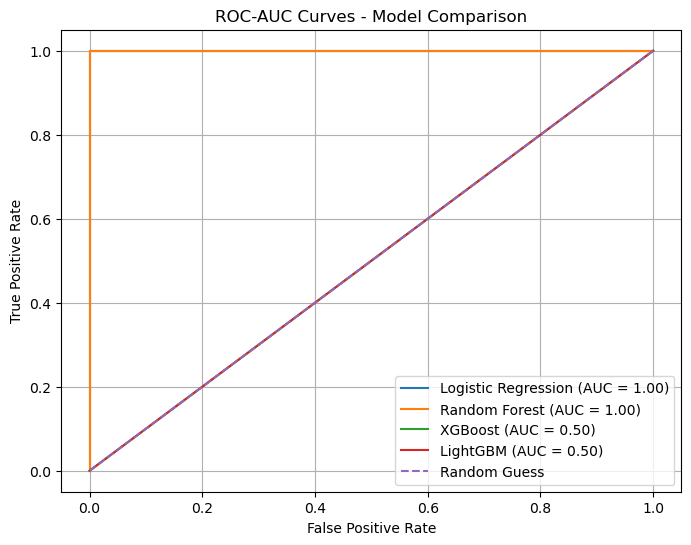

In [18]:
# ==========================================
# STEP 16: ROC-AUC Curves for All Models
# ==========================================

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

plt.figure(figsize=(8, 6))

for name, model in best_models.items():
    y_prob = model.predict_proba(X_test)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_score = roc_auc_score(y_test, y_prob)

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC = {auc_score:.2f})"
    )

# Random guessing line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Guess"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-AUC Curves - Model Comparison")
plt.legend()
plt.grid()
plt.show()

In [19]:
# ==========================================
# STEP 17: Save Champion Model
# ==========================================

import joblib

# Select Random Forest as champion model
champion_model = best_models["Random Forest"]

# Save the model
joblib.dump(champion_model, "champion_model.joblib")

# Save feature names used by the model
joblib.dump(list(X.columns), "feature_names.joblib")

print("Champion model saved successfully!")
print("Model: Random Forest")
print("Files created:")
print("- champion_model.joblib")
print("- feature_names.joblib")

Champion model saved successfully!
Model: Random Forest
Files created:
- champion_model.joblib
- feature_names.joblib


In [20]:
# ==========================================
# STEP 18: Final Champion Model Selection
# ==========================================

# Select champion based on highest F1-Score
champion_name = comparison_df.sort_values(
    by=["F1-Score", "ROC-AUC"],
    ascending=False
).iloc[0]["Model"]

champion_model = best_models[champion_name]

print("===================================")
print("FINAL CHAMPION MODEL")
print("===================================")
print("Model:", champion_name)

print("\nPerformance:")
champion_row = comparison_df[
    comparison_df["Model"] == champion_name
]

display(champion_row.round(4))

print("\nChampion model is ready for deployment.")

FINAL CHAMPION MODEL
Model: Random Forest

Performance:


,Model,Precision,Recall,F1-Score,ROC-AUC
1,Random Forest,1.0,1.0,1.0,1.0



Champion model is ready for deployment.


In [21]:
# ==========================================
# STEP 19: FINAL PROJECT VERIFICATION
# ==========================================

print("==========================================")
print("CUSTOMER CHURN ML - FINAL VERIFICATION")
print("==========================================")

print("\n1. Models trained:")
print(list(trained_models.keys()))

print("\n2. Hyperparameter tuning:")
print("Completed using GridSearchCV + Stratified K-Fold CV")

print("\n3. Champion model:")
print(champion_name)

print("\n4. Champion performance:")
print(champion_row.round(4).to_string(index=False))

print("\n5. Saved model:")
print("champion_model.joblib")

print("\n6. Saved feature information:")
print("feature_names.joblib")

print("\n==========================================")
print("PROJECT MODELING SECTION COMPLETED!")
print("==========================================")

CUSTOMER CHURN ML - FINAL VERIFICATION

1. Models trained:
['Logistic Regression', 'Random Forest', 'XGBoost', 'LightGBM']

2. Hyperparameter tuning:
Completed using GridSearchCV + Stratified K-Fold CV

3. Champion model:
Random Forest

4. Champion performance:
        Model  Precision  Recall  F1-Score  ROC-AUC
Random Forest        1.0     1.0       1.0      1.0

5. Saved model:
champion_model.joblib

6. Saved feature information:
feature_names.joblib

PROJECT MODELING SECTION COMPLETED!
